In [21]:
import pandas as pd
import nltk 
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk import RegexpParser
from nltk.tokenize import sent_tokenize 
from nltk import Tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from transformers import TFBertModel, AutoTokenizer
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cosine
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings
import time
from concurrent.futures import ThreadPoolExecutor
from transformers import logging
from matplotlib.ticker import MaxNLocator
import math
from transformers import pipeline
from functools import partial
from scipy.optimize import curve_fit
import json
import itertools
import networkx as nx
import statsmodels.api as sm

warnings.filterwarnings('ignore')
logging.set_verbosity_error()  # disable warnings from transformer, hugging face package.

## Process the data.

In [22]:
## get all the stories.  nine stories in total.
story_all = [] 

data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v1-pool.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/schissel_v2-lake.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v1-rookie.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/triplett_v2-catlady.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/panic.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v1-park.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/hester_v2-church.pkl")
story_all.append(data)
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/stein.pkl")
story_all.append(data)

In [23]:
story_all[0].keys()

print(story_all[0]['recall scores'])

5aa18536dbdb470001ef2cf1            [1, 2, 5, 7, 8, 9, 10, 14, 16, 17, 19]
5f0b196928879b23ce83e097                                    [7, 9, 11, 19]
5d5db7f7ca179000180b17cc         [1, 2, 5, 6, 7, 8, 9, 10, 11, 14, 16, 18]
5ac0eabce1546900019bd744    [2, 4, 5, 6, 7, 9, 10, 11, 12, 15, 16, 17, 19]
60693e637bc58fc13d57b1a7          [6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19]
                                                 ...                      
5ea806dea2d63e011f551ef6                              [1, 6, 7, 8, 17, 19]
5d95fc8c7f79070017f92e93       [1, 2, 5, 7, 8, 10, 13, 14, 16, 17, 18, 19]
5ceef0cd45c1ec001920d548                                    [2, 5, 14, 19]
63f7792ffa2f18ec31a85d24                            [2, 3, 5, 7, 8, 9, 14]
640226e83e2c4614c50dff0e                           [2, 5, 6, 7, 9, 17, 19]
Length: 100, dtype: object


In [24]:
## use the clauses in the original dataset.
story_processed_all = [story_all[i]['segmentation'] for i in np.arange(9)]
story_processed_marked = [string.split("\n") for string in story_processed_all]  # split into single clauses.
story_processed_all = [[item[3:] if item[2] == "." 
                        else item[2:] if item[1] == "."
                        else item[4:] for item in story_processed_marked[story]] for story in np.arange(9)]

recall_processed_all = [story_all[i]['recalls segmented'] for i in np.arange(len(story_processed_all))]
recall_processed_marked = [[participant.split("\n") for participant in recall_processed_all[story]]
                        for story in np.arange(9)]
recall_processed_all = [[ [element[3:] if len(element) > 2 and element[2] == "." else
                           element[2:] if len(element) > 2 and element[1] == "." else
                           element[4:] if len(element) > 2 else
                           ""  for element in participant] for participant in recall_processed_marked[story]]
                        for story in np.arange(9)]

score_processed_all = [story_all[i]['recall scores'] for i in np.arange(len(story_processed_all))]
for i in np.arange(len(score_processed_all)):
    recall_score_each = score_processed_all[i].values
    score_processed_all[i] = recall_score_each.tolist()
    # print(score_processed_all[i])

# print(story_processed_all[7])
# print(recall_processed_all[0][0])   # clear clause of each participant.
# print("")
# print("recalled narrative clauses:", score_processed_all)

In [25]:
## three more stories added to the analysis.
story_additional = [] 
recall_additional = []

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/bear-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-segments.csv", encoding='utf-8')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/costa-recalls_segmented.csv", encoding='utf-8')
recall_additional.append(recall)

data = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/do-something-segments.csv", encoding='ISO-8859-1')
story_additional.append(data)
recall = pd.read_csv("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/dosomething-recalls_segmented.csv", encoding='ISO-8859-1')
recall_additional.append(recall)


In [26]:
additional_story_processed = []
additional_recall_processed = [[] for _ in np.arange(3)]
score_processed_additional = []

for i in np.arange(3):
    # the original story in segment.
    story = story_additional[i]['segment_text']
    story_as_list = story.tolist()
    additional_story_processed.append(story_as_list)

    # get the recall text by each participant.
    recall = recall_additional[i]
    recall_id = recall['recall_id']
    recall_id_set = list(set(recall_id))
    for j in recall_id_set:
        recall_participant = recall[recall['recall_id'] == j]
        recall_content = recall_participant['clause_text']
        recall_as_list = recall_content.tolist()
        additional_recall_processed[i].append(recall_as_list)

    # get the recall score of each narrative clause. - the final score in the csv directly.
    score_processed_additional.append(story_additional[i]['proc'])
    score_processed_add = [series_item.tolist() for series_item in score_processed_additional]
    score_processed = [[float(p.strip('%')) for p in percent_list] 
                                      for percent_list in score_processed_add]


In [27]:
## add the new data to the dataset.
story_processed_all = story_processed_all + additional_story_processed
recall_processed_all = recall_processed_all + additional_recall_processed

clauses = [len(story_processed_all[i]) for i in np.arange(len(story_processed_all))]
print("clauses in each story: ", clauses )

clauses in each story:  [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]


In [28]:
### look at other data in the datasets.
data = pd.read_pickle("E:/83. find the next lab/15. rotation in Tankut's lab/story text dataset/boyscout.pkl")

data.keys()

data['recall scores']  # the recalled clause in the original story for each participant. need to calculate the recall percentage myself to get the score line.


5aa18536dbdb470001ef2cf1            [1, 2, 5, 7, 8, 9, 10, 14, 16, 17, 19]
5f0b196928879b23ce83e097                                    [7, 9, 11, 19]
5d5db7f7ca179000180b17cc         [1, 2, 5, 6, 7, 8, 9, 10, 11, 14, 16, 18]
5ac0eabce1546900019bd744    [2, 4, 5, 6, 7, 9, 10, 11, 12, 15, 16, 17, 19]
60693e637bc58fc13d57b1a7          [6, 7, 8, 9, 10, 14, 15, 16, 17, 18, 19]
                                                 ...                      
5ea806dea2d63e011f551ef6                              [1, 6, 7, 8, 17, 19]
5d95fc8c7f79070017f92e93       [1, 2, 5, 7, 8, 10, 13, 14, 16, 17, 18, 19]
5ceef0cd45c1ec001920d548                                    [2, 5, 14, 19]
63f7792ffa2f18ec31a85d24                            [2, 3, 5, 7, 8, 9, 14]
640226e83e2c4614c50dff0e                           [2, 5, 6, 7, 9, 17, 19]
Length: 100, dtype: object

In [29]:
model = SentenceTransformer('all-MiniLM-L6-v2')

story_emb_all = [model.encode(story) for story in story_processed_all]

recall_emb_all = [[model.encode(participant) for participant in story]
                    for story in recall_processed_all]

## Look at chunking distribution for several participants. - whether chunking is random.

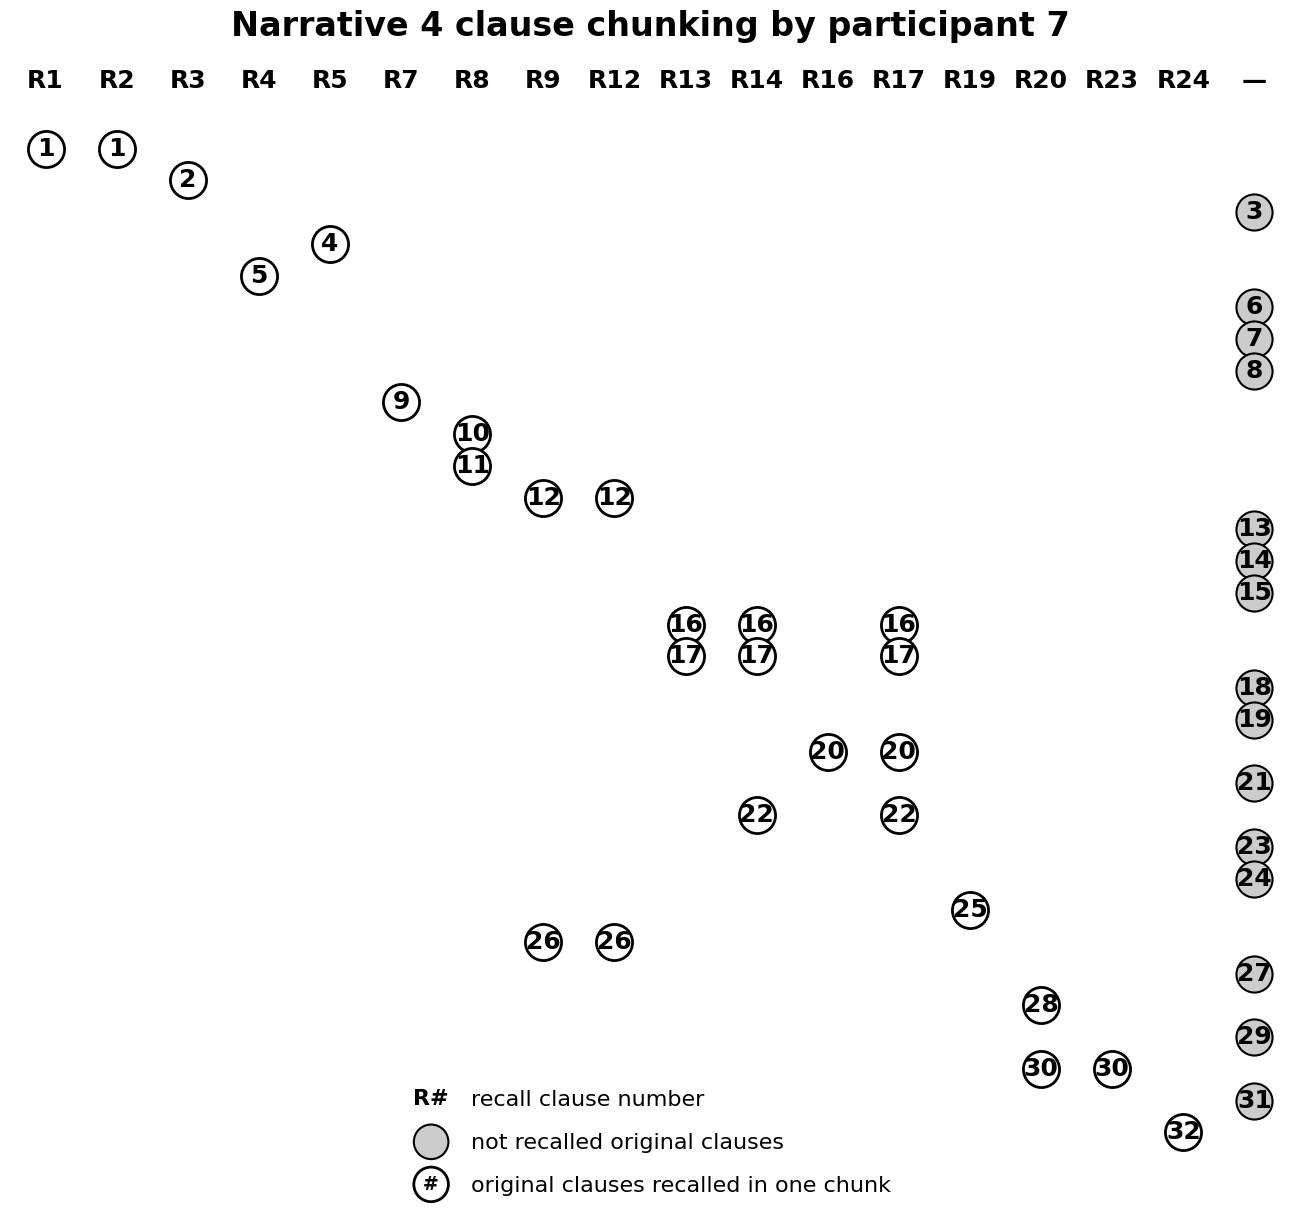

In [30]:
participant_index = 6
story_index = 3
weight_threshold = 0.5

original_sentence = story_processed_all[story_index]
original_index    = np.arange(1, len(story_processed_all[story_index]) + 1)
recall_sentence   = recall_processed_all[story_index][participant_index]
recall_index      = np.arange(1, len(recall_processed_all[story_index][participant_index]) + 1)


from collections import defaultdict
import matplotlib.cm as cm

orig_embs   = model.encode(original_sentence)
recall_embs = model.encode(recall_sentence)

recall_to_orig = defaultdict(list)
orig_to_recall = defaultdict(list)

for i, orig_emb in enumerate(orig_embs):
    for j, rec_emb in enumerate(recall_embs):
        w = round(1 - cosine(orig_emb, rec_emb), 2)
        if w > weight_threshold:
            recall_to_orig[recall_index[j]].append(original_index[i])
            orig_to_recall[original_index[i]].append(recall_index[j])

# ── plot ───────────────────────────────────────────────────────────────────────
unique_recall  = sorted(recall_to_orig.keys())
colors         = cm.tab10(np.linspace(0, 1, max(len(unique_recall), 1)))
recall_colors  = {r: colors[i] for i, r in enumerate(unique_recall)}

matched_nums   = set(orig_to_recall.keys())
unmatched_nums = [n for n in original_index if n not in matched_nums]

col_spacing  = 0.7
node_spacing = 0.35
n_orig       = len(original_index)
n_cols       = len(unique_recall) + 1

fig, ax = plt.subplots(figsize=(max(n_cols * col_spacing + 0.5, 3),
                                max(n_orig * node_spacing + 1.0, 3)))

# ── matched columns ───────────────────────────────────────────────────────────
for gi, recall_num in enumerate(unique_recall):
    x = gi * col_spacing

    ax.text(x, 0.4, f"R{recall_num}", ha='center', va='center',
            fontsize=18, fontweight='bold', color='black')

    for num in recall_to_orig[recall_num]:
        y = -num * node_spacing
        ax.plot(x, y, 'o', markersize=26, color='white',
                markeredgecolor='black', markeredgewidth=2.0, zorder=3)
        ax.text(x, y, str(num), ha='center', va='center',
                fontsize=18, fontweight='bold', color='black', zorder=4)

# ── unmatched column (rightmost) ──────────────────────────────────────────────
x_grey = len(unique_recall) * col_spacing
ax.text(x_grey, 0.4, "—", ha='center', va='center',
        fontsize=18, fontweight='bold', color='black')

for num in unmatched_nums:
    y = -num * node_spacing
    ax.plot(x_grey, y, 'o', markersize=26, color='#CCCCCC',
            markeredgecolor='black', markeredgewidth=1.5, zorder=3)
    ax.text(x_grey, y, str(num), ha='center', va='center',
            fontsize=18, fontweight='bold', color='black', zorder=4)

ax.set_title(f"Narrative {story_index+1} clause chunking by participant {participant_index+1}",
             fontsize=24, fontweight='bold')

ax.set_xlim(-col_spacing * 0.5, x_grey + col_spacing * 0.5)
ax.set_ylim(-(n_orig + 1) * node_spacing, 0.8)
ax.axis('off')

from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
import matplotlib.patches as mpatches
import matplotlib.text as mtext

class TextHandle(HandlerBase):
    def __init__(self, text):
        self.text = text
        super().__init__()
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        cx = width/2 - xdescent
        cy = height/2 - ydescent
        return [mtext.Text(cx, cy, self.text, ha='center', va='center',
                           fontsize=fontsize, fontweight='bold', transform=trans)]

class CircleHandle(HandlerBase):
    def __init__(self, symbol='', fc='white', ec='black', lw=2.0):
        self.symbol = symbol
        self.fc = fc; self.ec = ec; self.lw = lw
        super().__init__()
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        cx = width/2 - xdescent
        cy = height/2 - ydescent
        r  = min(width, height) * 0.55
        artists = [mpatches.Circle((cx, cy), r, facecolor=self.fc,
                                    edgecolor=self.ec, linewidth=self.lw, transform=trans)]
        if self.symbol:
            artists.append(mtext.Text(cx, cy, self.symbol, ha='center', va='center',
                                      fontsize=fontsize * 0.85, fontweight='bold', transform=trans))
        return artists

h1 = mpatches.Patch(visible=False)
h2 = mpatches.Patch(visible=False)
h3 = mpatches.Patch(visible=False)

ax.legend(
    handles=[h1, h2, h3],
    labels=['recall clause number',
            'not recalled original clauses',
            'original clauses recalled in one chunk'],
    handler_map={
        h1: TextHandle('R#'),
        h2: CircleHandle(fc='#CCCCCC', ec='black', lw=1.5),
        h3: CircleHandle(symbol='#', fc='white', ec='black', lw=2.0),
    },
    loc='lower center', bbox_to_anchor=(0.5, -0.05),
    fontsize=16, frameon=False, ncol=1,
    handlelength=2, handleheight=1.8
)

plt.tight_layout()
plt.show()


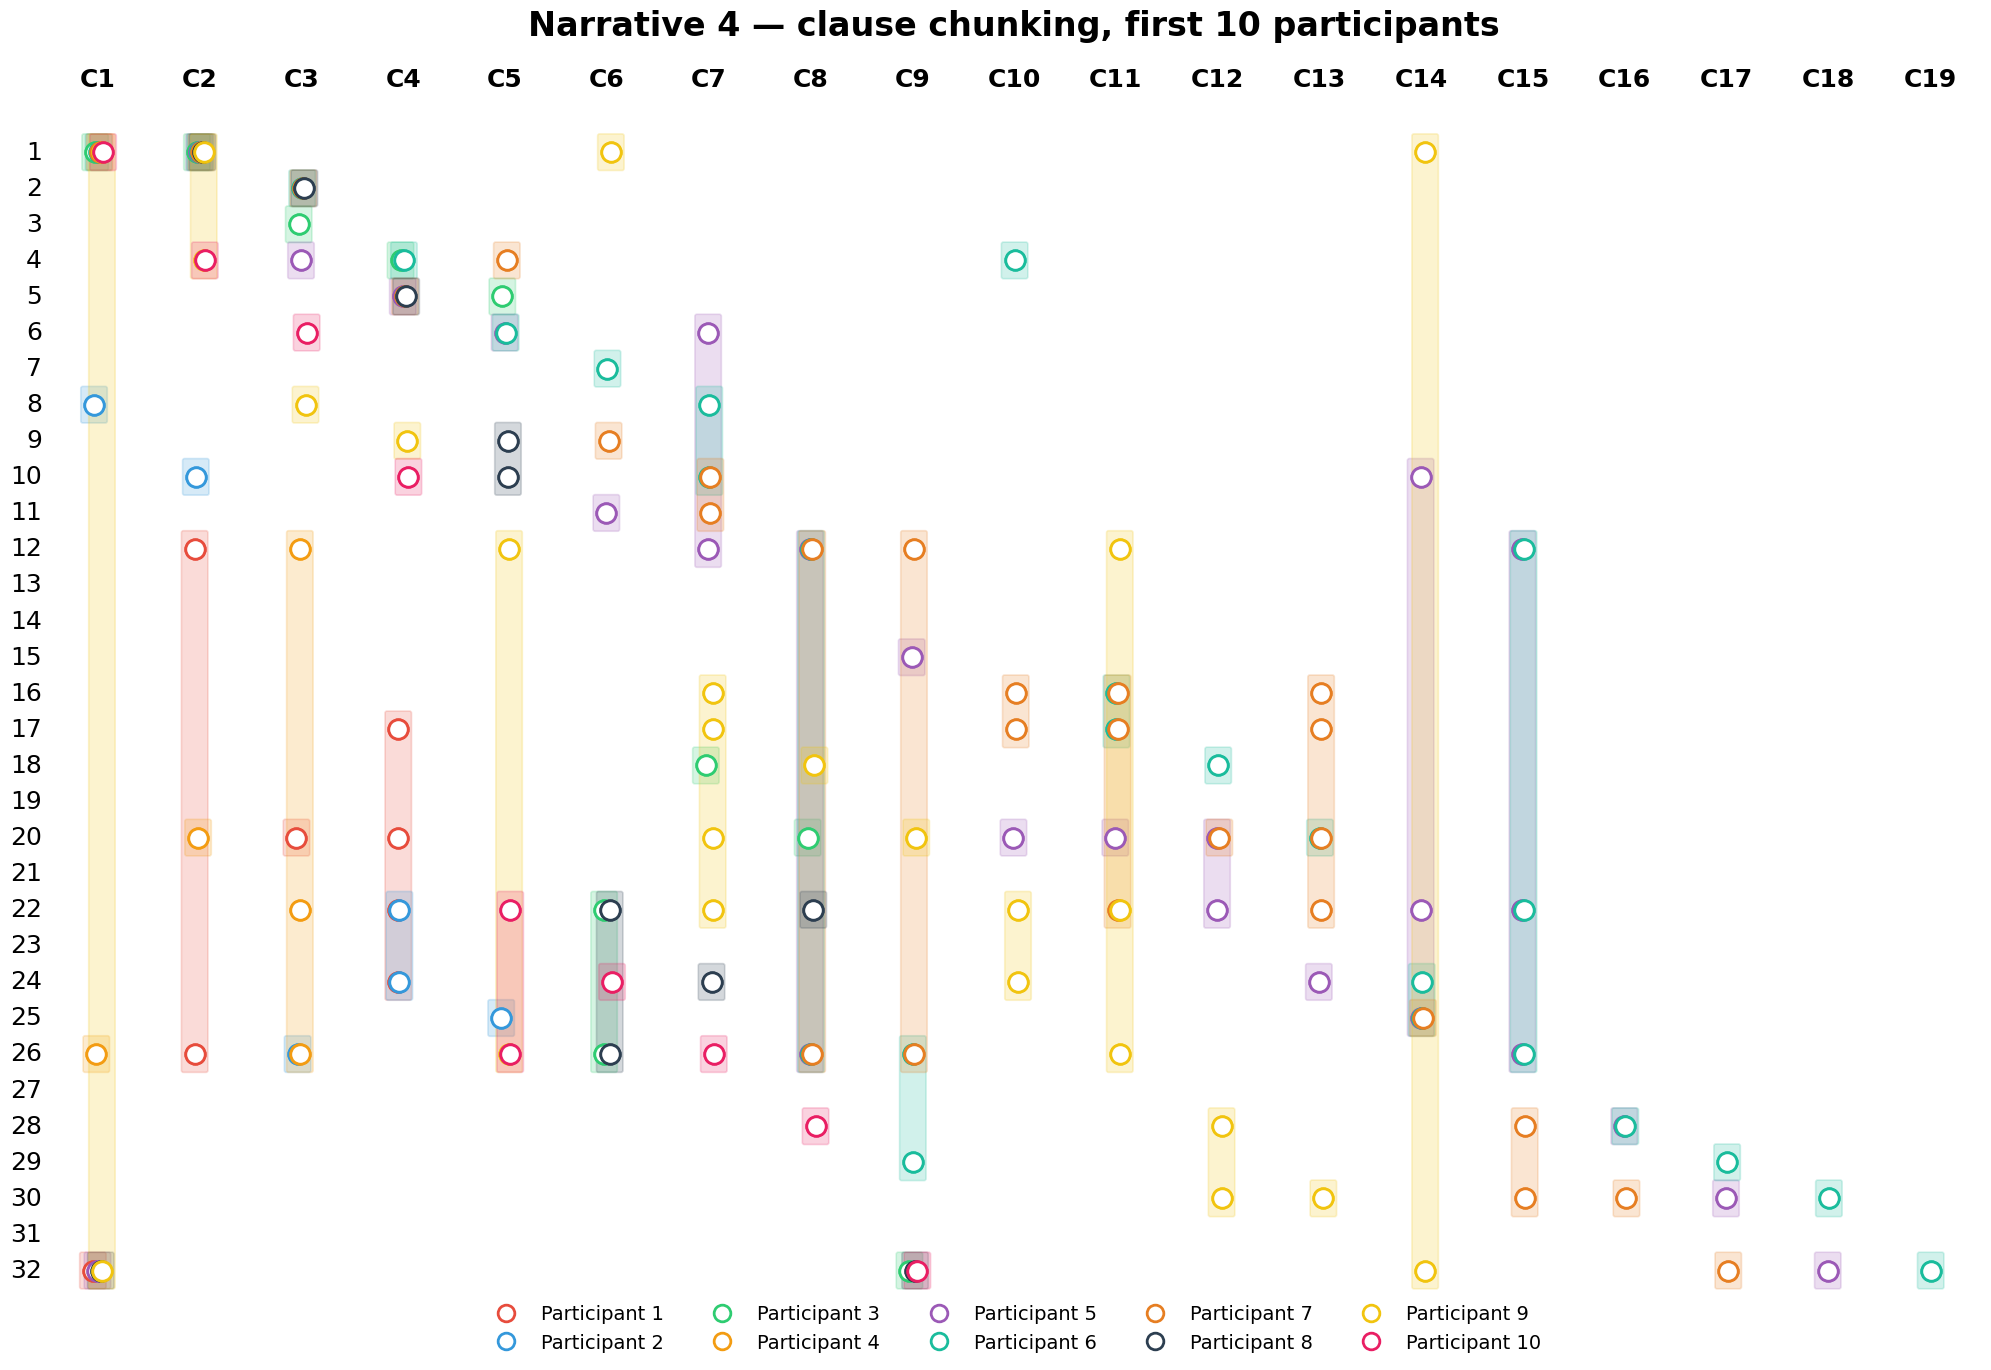

In [31]:
n_participants_plot = 10
participant_colors = [
    '#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6',
    '#1ABC9C', '#E67E22', '#2C3E50', '#F1C40F', '#E91E63'
]


orig_embs = model.encode(original_sentence)

all_data = []
for p in range(n_participants_plot):
    rec_sent = recall_processed_all[story_index][p]
    rec_idx  = np.arange(1, len(rec_sent) + 1)
    rec_embs = model.encode(rec_sent)
    r2o = defaultdict(list)
    for i, oe in enumerate(orig_embs):
        for j, re in enumerate(rec_embs):
            w = round(1 - cosine(oe, re), 2)
            if w > weight_threshold:
                r2o[rec_idx[j]].append(original_index[i])
    all_data.append({'r2o': r2o, 'unique': sorted(r2o.keys())})

# ── layout ─────────────────────────────────────────────────────────────────────
col_spacing  = 1.0
node_spacing = 0.35
n_orig       = len(original_index)
max_chunks   = max(len(d['unique']) for d in all_data)
jitter       = np.linspace(-0.18, 0.18, n_participants_plot)

fig, ax = plt.subplots(figsize=(max(max_chunks * col_spacing + 1, 5),
                                max(n_orig * node_spacing + 2.5, 4)))

# ── column headers ─────────────────────────────────────────────────────────────
for gi in range(max_chunks):
    ax.text(gi * col_spacing, 0.35, f"C{gi+1}", ha='center', va='center',
            fontsize=18, fontweight='bold', color='black')

    
jitter = np.linspace(-0.05, 0.05, n_participants_plot)

# ── draw all participants ──────────────────────────────────────────────────────
for p in range(n_participants_plot):
    pcolor   = participant_colors[p]
    r2o      = all_data[p]['r2o']
    unique_r = all_data[p]['unique']

    for gi, rn in enumerate(unique_r):
        xc = gi * col_spacing + jitter[p]
        for num in r2o[rn]:
            y = -num * node_spacing
            ax.plot(xc, y, 'o', markersize=14, color='white',
                    markeredgecolor=pcolor, markeredgewidth=2.0, zorder=3+p)

for num in original_index:
    y = -num * node_spacing
    ax.text(-col_spacing * 0.5 - 0.05, y, str(num), ha='right', va='center',
            fontsize=18, color='black')

import matplotlib.patches as mpatches

band_w = 0.22   # width of each shaded band

for p in range(n_participants_plot):
    pcolor   = participant_colors[p]
    r2o      = all_data[p]['r2o']
    unique_r = all_data[p]['unique']

    for gi, rn in enumerate(unique_r):
        xc   = gi * col_spacing + jitter[p]
        nums = r2o[rn]

        # ── shaded band behind the chunk ──────────────────────────────────────
        if len(nums) >= 1:
            y_top = -min(nums) * node_spacing + node_spacing * 0.45
            y_bot = -max(nums) * node_spacing - node_spacing * 0.45
            ax.add_patch(mpatches.FancyBboxPatch(
                (xc - band_w / 2, y_bot), band_w, y_top - y_bot,
                boxstyle="round,pad=0.02",
                facecolor=pcolor, alpha=0.2,
                edgecolor=pcolor, linewidth=1.2,
                zorder=2
            ))

        # ── circles ───────────────────────────────────────────────────────────
        for num in nums:
            y = -num * node_spacing
            ax.plot(xc, y, 'o', markersize=14, color='white',
                    markeredgecolor=pcolor, markeredgewidth=2.0, zorder=3 + p)


# ── legend ─────────────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor=participant_colors[p], markeredgewidth=2.0,
           markersize=12, label=f'Participant {p+1}')
    for p in range(n_participants_plot)
]
ax.legend(handles=legend_handles, fontsize=14, frameon=False,
          loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=5)

ax.set_xlim(-col_spacing * 0.5, (max_chunks - 0.5) * col_spacing)
ax.set_ylim(-(n_orig + 1) * node_spacing, 0.7)
ax.axis('off')
ax.set_title(f"Narrative {story_index+1} — clause chunking, first {n_participants_plot} participants",
             fontsize=24, fontweight='bold')

plt.tight_layout()
plt.show()


In [32]:
## print out clauses from the same chunk.
for p in range(n_participants_plot):
    r2o      = all_data[p]['r2o']
    unique_r = all_data[p]['unique']

    # collect all matched clause indices for this participant
    matched = set(idx for idxs in r2o.values() for idx in idxs)
    unmatched = [n for n in original_index if n not in matched]

    print(f"\n{'='*60}")
    print(f"Participant {p+1}")

    for gi, rn in enumerate(unique_r):
        print(f"\n  C{gi+1} (R{rn}):")
        for clause_idx in sorted(r2o[rn]):
            text = story_processed_all[story_index][clause_idx - 1]
            print(f"    [{clause_idx}] {text}")

    if unmatched:
        print(f"\n  — (not recalled):")
        for clause_idx in sorted(unmatched):
            text = story_processed_all[story_index][clause_idx - 1]
            print(f"    [{clause_idx}] {text}")



Participant 1

  C1 (R1):
    [32]  That was the end of my rookie year.

  C2 (R3):
    [12]  Then she left a message one day saying she was going to run away because he was always scolding her about me.
    [26]  She hadn't run away.

  C3 (R5):
    [20]  And we went to where they found her scarf – near a park.

  C4 (R6):
    [17]  and if we can't locate her well you can – do whatever you think is right.”
    [20]  And we went to where they found her scarf – near a park.
    [22]  and we couldn't locate her.
    [24]  – it was a police station –

  — (not recalled):
    [1]  Back in the days when I was a rookie in the police force, the Chief was a veteran.
    [2]  He had caught a notorious criminal –
    [3]  or had been awarded for bravery.
    [4]  But he had – a young daughter.
    [5]  And in those days I was a fitness enthusiast.
    [6]  And it seemed she was trying to impress me.
    [7]  I never observed it.
    [8]  Truth is I wasn't very fond of her because she was –
    

## Calculate F_in for all dataset.

In [33]:
F_in = [[] for i in np.arange(12)]
model = SentenceTransformer('all-MiniLM-L6-v2')

###### connection threshold
def convert_degree_threshold(degree):
    th = 1 - math.cos(math.radians(degree))
    return th

distance_angle = 60
distance_threshold = convert_degree_threshold(distance_angle)  # 1 - cosine(75°).  cosine distance.
weight_threshold = 1 - distance_threshold



def compute_F_in_for_participant(story_index, participant_index, 
                                 story_emb_all, recall_emb_all):
    """
    Worker function to compute F_in value for one participant.
    """
    participant = recall_emb_all[story_index][participant_index]
    if len(participant) <= 1:
        return None  # skip empty recalls
    
    F_in_value = 0
    F_in_each_clause = []

    ## data from narratives and recalls
    original_sentence = story_emb_all[story_index]
    recall_sentence = participant

    for j in np.arange(len(recall_sentence)):
        clause_compress_count = 0
        for i in np.arange(len(original_sentence)):
            sim = 1 - cosine(story_emb_all[story_index][i], 
                             recall_emb_all[story_index][participant_index][j])
            if round(sim, 2) > weight_threshold:  # screen again
                F_in_value += 1
                clause_compress_count += 1
        F_in_each_clause.append(clause_compress_count) 

    ## get the number of original clauses in each recalled clause.
    F_in_each_clause = {story_index: F_in_each_clause}
    
    return F_in_value / len(recall_sentence), F_in_each_clause


def compute_F_in_for_story(story_index, story_emb_all, recall_emb_all):
    """
    Parallel compute all participants for one story.
    """
    results = []
    with ThreadPoolExecutor() as executor:
        futures = {
            executor.submit(compute_F_in_for_participant, story_index, i,
                            story_emb_all, recall_emb_all): i
            for i, _ in enumerate(recall_emb_all[story_index])
        }

        for future in as_completed(futures):
            result = future.result()
            if result is not None:
                results.append(result)
            # print(f"recall {futures[future]+1} finished.")
    return results


# ---- Main Loop ----
clause_compress_tree = {}
for story in np.arange(12):
    F_in[story], clause_compress_tree[story] = zip(*compute_F_in_for_story(story, story_emb_all, recall_emb_all))
    print(f"story {story+1} finished.")


F_in_mean = [np.mean(item) for item in F_in]
print(F_in_mean)

story 1 finished.
story 2 finished.
story 3 finished.
story 4 finished.
story 5 finished.
story 6 finished.
story 7 finished.
story 8 finished.
story 9 finished.
story 10 finished.
story 11 finished.
story 12 finished.
[0.9944520168338643, 0.995937528944065, 1.2704073987237252, 0.9560027516899107, 0.9897092655378339, 1.8887820330610021, 1.5699461475112706, 1.5139434300412233, 1.6236206766872072, 3.4937108425196897, 4.692649698305176, 1.3616227970466637]


In [34]:
## put all counts for the same story in a sub-data array.
clause_compress_data = [[] for i in np.arange(12)]

for i in np.arange(12):
    combined = {}  # new dictionary to store combined sublists
    for d in clause_compress_tree[i]:
        for k, v in d.items():
            combined.setdefault(k, []).append(v)
    clause_compress_data[i] = list(combined.values())


In [35]:
# store the data of clauses for the tree calculation.
with open("recall_data_4tree.json", "w") as f:
    json.dump(clause_compress_data, f)

Story 1: n=98, SD=0.3641, SE=0.0368
Story 2: n=54, SD=0.3300, SE=0.0449
Story 3: n=98, SD=0.3735, SE=0.0377
Story 4: n=99, SD=0.3502, SE=0.0352
Story 5: n=98, SD=0.3403, SE=0.0344
Story 6: n=100, SD=0.7098, SE=0.0710
Story 7: n=98, SD=0.5618, SE=0.0568
Story 8: n=100, SD=0.7263, SE=0.0726
Story 9: n=97, SD=0.5998, SE=0.0609
Story 10: n=100, SD=0.8912, SE=0.0891
Story 11: n=93, SD=1.5851, SE=0.1644
Story 12: n=94, SD=0.4970, SE=0.0513


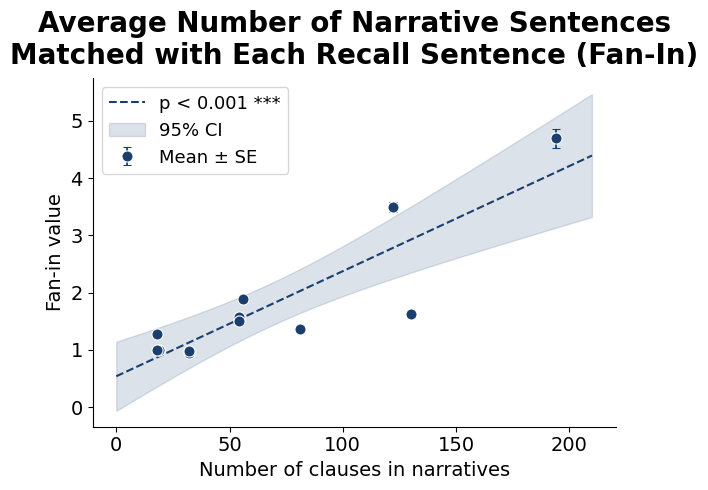

In [38]:
###### plot.
clause_story = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]
F_in_std = [np.std(item, ddof=1) for item in F_in]

# SE of the mean chunk size (F_in) for each story, from all participants:
# n_i = number of participants for story i, sigma_i = SD across those
# participants' F_in values. Fisher information for the mean: I_i(mu) = n_i/sigma_i^2
# -> SE(mu_hat_i) = sqrt(1/I_i) = sigma_i / sqrt(n_i)
n_participants_per_story = [len(item) for item in F_in]
F_in_se = [F_in_std[i] / np.sqrt(n_participants_per_story[i]) for i in range(12)]

for i in range(12):
    print(f"Story {i+1}: n={n_participants_per_story[i]}, "
          f"SD={F_in_std[i]:.4f}, SE={F_in_se[i]:.4f}")

from scipy.interpolate import PchipInterpolator

X      = sm.add_constant(clause_story)
model01 = sm.OLS(F_in_mean, X).fit()
intercept, slope = model01.params
p_value = model01.pvalues[1]

x_reg  = np.linspace(0, 210, 300)
X_pred = sm.add_constant(x_reg)
pred   = model01.get_prediction(X_pred).summary_frame(alpha=0.05)

if p_value < 0.001:
    p_label = "p < 0.001 ***"
elif p_value < 0.01:
    p_label = f"p = {p_value:.3f} **"
elif p_value < 0.05:
    p_label = f"p = {p_value:.3f} *"
else:
    p_label = f"p = {p_value:.3f}"

fig, ax = plt.subplots(figsize=(6, 5))

ax.errorbar(clause_story, F_in_mean, yerr=F_in_se,
            fmt='o', color='#1a3f6f', ecolor='#1a3f6f', elinewidth=1.3,
            capsize=3, markersize=8, zorder=3, markeredgecolor='white',
            markeredgewidth=0.8, label='Mean ± SE')
ax.plot(x_reg, pred['mean'], "--", color='#1a3f6f', lw=1.5, label=p_label)
ax.fill_between(x_reg, pred['mean_ci_lower'], pred['mean_ci_upper'],
                color='#1a3f6f', alpha=0.15, label='95% CI')

ax.set_title("Average Number of Narrative Sentences\nMatched with Each Recall Sentence (Fan-In)",
             fontsize=20, pad=10, fontweight='bold')
ax.set_ylabel("Fan-in value", fontsize=14)
ax.set_xlabel("Number of clauses in narratives", fontsize=14)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fanin_vs_clauses.png', dpi=150, bbox_inches='tight')
plt.show()


In [36]:
from scipy import stats as sp_stats
import statsmodels.api as sm

x     = np.array(clause_story, dtype=float)
y_arr = np.array(F_in_mean,    dtype=float)
n     = len(x)
df    = n - 2

# ── parametric ──
X_sm     = sm.add_constant(x)
model01  = sm.OLS(y_arr, X_sm).fit()
intercept, slope = model01.params
slope_ci = model01.conf_int(alpha=0.05)[1]
r_p, _   = sp_stats.pearsonr(x, y_arr)
r2       = r_p**2
cohen_f2 = r2 / (1 - r2)
t_obs    = r_p * np.sqrt(df) / np.sqrt(1 - r_p**2)
t_crit   = sp_stats.t.ppf(0.975, df)
power    = 1 - sp_stats.t.cdf(t_crit, df, loc=abs(t_obs)) + sp_stats.t.cdf(-t_crit, df, loc=abs(t_obs))
z_r      = np.arctanh(r_p)
se_z     = 1 / np.sqrt(n - 3)
ci_r_low  = np.tanh(z_r - 1.96 * se_z)
ci_r_high = np.tanh(z_r + 1.96 * se_z)

print("=" * 55)
print("  PARAMETRIC")
print("=" * 55)
print(f"  n              = {n}")
print(f"  slope          = {slope:.4f}")
print(f"  95% CI slope   = [{slope_ci[0]:.4f}, {slope_ci[1]:.4f}]")
print(f"  intercept      = {intercept:.4f}")
print(f"  t({df})         = {t_obs:.4f}")
print(f"  p              = {model01.pvalues[1]:.4e}")
print(f"  Pearson r      = {r_p:.4f}")
print(f"  R²             = {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"  Fisher CI on r = [{ci_r_low:.4f}, {ci_r_high:.4f}]")
print(f"  Cohen's f²     = {cohen_f2:.4f}  ({'small' if cohen_f2<0.15 else 'medium' if cohen_f2<0.35 else 'large'})")
print(f"  Power          = {power:.4f}  (α=0.05)")

# ── permutation ──
n_perm   = 10000
r_perm   = np.zeros(n_perm)
sl_perm  = np.zeros(n_perm)
r2_perm  = np.zeros(n_perm)
for i in range(n_perm):
    y_shuf      = np.random.permutation(y_arr)
    r_perm[i], _ = sp_stats.pearsonr(x, y_shuf)
    m_p         = sm.OLS(y_shuf, X_sm).fit()
    sl_perm[i]  = m_p.params[1]
    r2_perm[i]  = m_p.rsquared

p_perm_r  = np.mean(np.abs(r_perm)  >= np.abs(r_p))
p_perm_sl = np.mean(np.abs(sl_perm) >= np.abs(slope))
ci_perm_r  = [np.percentile(r_perm, 2.5),  np.percentile(r_perm, 97.5)]
ci_perm_sl = [np.percentile(sl_perm, 2.5), np.percentile(sl_perm, 97.5)]
f2_perm    = np.mean(r2_perm) / (1 - np.mean(r2_perm))

print(f"\n{'=' * 55}")
print(f"  PERMUTATION (n={n_perm})")
print(f"{'=' * 55}")
print(f"  p (r)          = {p_perm_r:.4f}")
print(f"  p (slope)      = {p_perm_sl:.4f}")
print(f"  null CI on r   = [{ci_perm_r[0]:.4f}, {ci_perm_r[1]:.4f}]")
print(f"  null CI slope  = [{ci_perm_sl[0]:.4f}, {ci_perm_sl[1]:.4f}]")
print(f"  mean null R²   = {np.mean(r2_perm):.4f}")
print(f"  mean null f²   = {f2_perm:.4f}")

# ── bootstrap ──
n_boot   = 10000
r_boot   = np.zeros(n_boot)
sl_boot  = np.zeros(n_boot)
r2_boot  = np.zeros(n_boot)
t_boot   = np.zeros(n_boot)
f2_boot  = np.zeros(n_boot)
for i in range(n_boot):
    idx = np.random.choice(n, n, replace=True)
    xb, yb = x[idx], y_arr[idx]
    if len(np.unique(xb)) < 2:
        continue
    r_boot[i], _ = sp_stats.pearsonr(xb, yb)
    m_b          = sm.OLS(yb, sm.add_constant(xb)).fit()
    sl_boot[i]   = m_b.params[1]
    r2_boot[i]   = m_b.rsquared
    t_boot[i]    = r_boot[i] * np.sqrt(n-2) / np.sqrt(1 - r_boot[i]**2 + 1e-10)
    f2_boot[i]   = r2_boot[i] / (1 - r2_boot[i] + 1e-10)

p_boot       = 2 * min(np.mean(r_boot <= 0), np.mean(r_boot >= 0))
ci_r_b       = [np.percentile(r_boot,  2.5), np.percentile(r_boot,  97.5)]
ci_sl_b      = [np.percentile(sl_boot, 2.5), np.percentile(sl_boot, 97.5)]
ci_r2_b      = [np.percentile(r2_boot, 2.5), np.percentile(r2_boot, 97.5)]
ci_f2_b      = [np.percentile(f2_boot, 2.5), np.percentile(f2_boot, 97.5)]
power_boot   = np.mean(np.abs(t_boot) >= t_crit)

print(f"\n{'=' * 55}")
print(f"  BOOTSTRAP (n={n_boot})")
print(f"{'=' * 55}")
print(f"  p              = {p_boot:.4f}")
print(f"  slope          = {np.mean(sl_boot):.4f}")
print(f"  95% CI slope   = [{ci_sl_b[0]:.4f}, {ci_sl_b[1]:.4f}]")
print(f"  Pearson r      = {np.mean(r_boot):.4f}")
print(f"  95% CI on r    = [{ci_r_b[0]:.4f}, {ci_r_b[1]:.4f}]")
print(f"  R²             = {np.mean(r2_boot):.4f}")
print(f"  95% CI on R²   = [{ci_r2_b[0]:.4f}, {ci_r2_b[1]:.4f}]")
print(f"  Cohen's f²     = {np.mean(f2_boot):.4f}")
print(f"  95% CI on f²   = [{ci_f2_b[0]:.4f}, {ci_f2_b[1]:.4f}]")
print(f"  Power          = {power_boot:.4f}")
print("=" * 55)


  PARAMETRIC
  n              = 12
  slope          = 0.0183
  95% CI slope   = [0.0113, 0.0254]
  intercept      = 0.5418
  t(10)         = 5.7917
  p              = 1.7493e-04
  Pearson r      = 0.8777
  R²             = 0.7703  (77.0% variance explained)
  Fisher CI on r = [0.6121, 0.9653]
  Cohen's f²     = 3.3543  (large)
  Power          = 0.9974  (α=0.05)

  PERMUTATION (n=10000)
  p (r)          = 0.0013
  p (slope)      = 0.0013
  null CI on r   = [-0.4391, 0.6913]
  null CI slope  = [-0.0092, 0.0144]
  mean null R²   = 0.0917
  mean null f²   = 0.1010

  BOOTSTRAP (n=10000)
  p              = 0.0002
  slope          = 0.0172
  95% CI slope   = [0.0050, 0.0237]
  Pearson r      = 0.8467
  95% CI on r    = [0.5596, 0.9909]
  R²             = 0.7316
  95% CI on R²   = [0.3132, 0.9820]
  Cohen's f²     = 8.5630
  95% CI on f²   = [0.4560, 54.4250]
  Power          = 0.9689



  Leave-One-Out Analysis — Fan-In (n=12)
  Left out     slope        r      R²           p  sig
  -------------------------------------------------------
         1   0.01851   0.8719  0.7601  4.6805e-04  ***
         2   0.01855   0.8721  0.7606  4.6415e-04  ***
         3   0.01903   0.8826  0.7790  3.2063e-04  ***
         4   0.01812   0.8721  0.7605  4.6494e-04  ***
         5   0.01816   0.8722  0.7607  4.6347e-04  ***
         6   0.01845   0.8820  0.7779  3.2830e-04  ***
         7   0.01835   0.8773  0.7697  3.8793e-04  ***
         8   0.01832   0.8770  0.7691  3.9222e-04  ***
         9   0.02139   0.9570  0.9159  3.8950e-06  ***
        10   0.01692   0.8717  0.7599  4.7003e-04  ***
        11   0.01317   0.7218  0.5209  1.2155e-02  *
        12   0.01863   0.8951  0.8011  1.9731e-04  ***
  -------------------------------------------------------
  slope range: [0.01317, 0.02139]
  r     range: [0.7218, 0.9570]
  R²    range: [0.5209, 0.9159]
  all p < 0.05: True


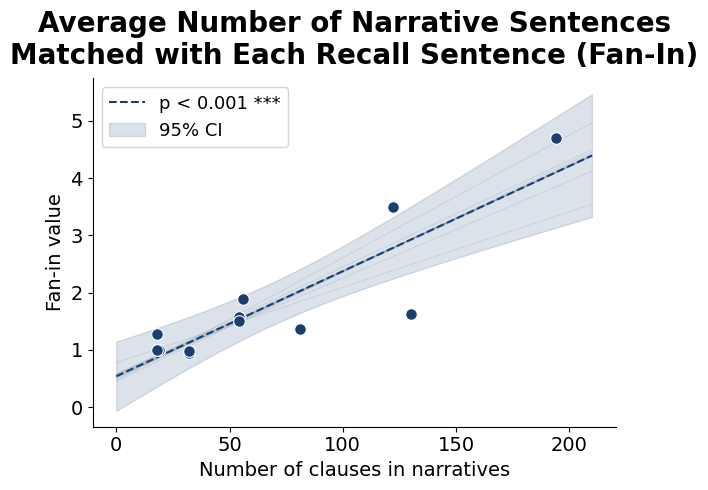

In [37]:
## leave-one-out test.
from scipy import stats as sp_stats

x_loo = np.array(clause_story)
y_loo = np.array(F_in_mean)
n_loo = len(x_loo)

loo_slopes, loo_intercepts, loo_r, loo_p = [], [], [], []
for i in range(n_loo):
    mask    = np.ones(n_loo, dtype=bool)
    mask[i] = False
    sl, ic, r_i, p_i, _ = sp_stats.linregress(x_loo[mask], y_loo[mask])
    loo_slopes.append(sl)
    loo_intercepts.append(ic)
    loo_r.append(r_i)
    loo_p.append(p_i)

loo_slopes = np.array(loo_slopes)
loo_r      = np.array(loo_r)
loo_p      = np.array(loo_p)

def sig(p): return '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'

print(f"\n{'='*60}")
print(f"  Leave-One-Out Analysis — Fan-In (n={n_loo})")
print(f"{'='*60}")
print(f"  {'Left out':>8}  {'slope':>8}  {'r':>7}  {'R²':>6}  {'p':>10}  sig")
print(f"  {'-'*55}")
for i in range(n_loo):
    print(f"  {i+1:>8}  {loo_slopes[i]:>8.5f}  {loo_r[i]:>7.4f}  "
          f"{loo_r[i]**2:>6.4f}  {loo_p[i]:>10.4e}  {sig(loo_p[i])}")
print(f"  {'-'*55}")
print(f"  slope range: [{loo_slopes.min():.5f}, {loo_slopes.max():.5f}]")
print(f"  r     range: [{loo_r.min():.4f}, {loo_r.max():.4f}]")
print(f"  R²    range: [{(loo_r**2).min():.4f}, {(loo_r**2).max():.4f}]")
print(f"  all p < 0.05: {np.all(loo_p < 0.05)}")
print(f"{'='*60}")

# ── plot with LOO lines ───────────────────────────────────────────────────────
x_reg  = np.linspace(0, 210, 300)
X_pred = sm.add_constant(x_reg)
pred   = model01.get_prediction(X_pred).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(6, 5))

for j in range(n_loo):
    ax.plot(x_reg, loo_intercepts[j] + loo_slopes[j] * x_reg,
            '-', color='#1a3f6f', lw=0.5, alpha=0.15)

ax.scatter(clause_story, F_in_mean, color='#1a3f6f', s=70, zorder=3,
           edgecolors='white', linewidths=0.8)
ax.plot(x_reg, pred['mean'], "--", color='#1a3f6f', lw=1.5, label=p_label)
ax.fill_between(x_reg, pred['mean_ci_lower'], pred['mean_ci_upper'],
                color='#1a3f6f', alpha=0.15, label='95% CI')

ax.set_title("Average Number of Narrative Sentences\nMatched with Each Recall Sentence (Fan-In)",
             fontsize=20, pad=10, fontweight='bold')
ax.set_ylabel("Fan-in value", fontsize=14)
ax.set_xlabel("Number of clauses in narratives", fontsize=14)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


## Sensitivity test.

In [10]:
import math, numpy as np, statsmodels.api as sm
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

angles      = [55, 60, 65]
colors      = ['#2471a3', '#e74c3c', '#27ae60']
clause_story = [19, 18, 18, 32, 32, 56, 54, 54, 130, 122, 194, 81]

def convert_degree_threshold(degree):
    return 1 - math.cos(math.radians(degree))

# ── core computation (threshold passed explicitly) ────────────────────────────
def compute_F_in_participant(story_idx, part_idx, story_emb_all, recall_emb_all, wt):
    participant = recall_emb_all[story_idx][part_idx]
    if len(participant) <= 1:
        return None
    F_in_value, F_in_each = 0, []
    for j in range(len(participant)):
        count = 0
        for i in range(len(story_emb_all[story_idx])):
            sim = 1 - cosine(story_emb_all[story_idx][i],
                             recall_emb_all[story_idx][part_idx][j])
            if round(sim, 2) > wt:
                F_in_value += 1
                count += 1
        F_in_each.append(count)
    return F_in_value / len(participant), {story_idx: F_in_each}

def compute_F_in_story(story_idx, story_emb_all, recall_emb_all, wt):
    results = []
    with ThreadPoolExecutor() as ex:
        futures = {
            ex.submit(compute_F_in_participant, story_idx, i,
                      story_emb_all, recall_emb_all, wt): i
            for i in range(len(recall_emb_all[story_idx]))
        }
        for f in as_completed(futures):
            r = f.result()
            if r is not None:
                results.append(r)
    return results

# ── sensitivity loop ──────────────────────────────────────────────────────────
sensitivity_results = {}

for angle in angles:
    wt = 1 - convert_degree_threshold(angle)

    F_in = [[] for _ in range(12)]
    for story in range(12):
        vals_trees = compute_F_in_story(story, story_emb_all, recall_emb_all, wt)
        F_in[story], _ = zip(*vals_trees)
        print(f"  [{angle}°] story {story+1} done")

    F_in_mean = [np.mean(v) for v in F_in]

    X        = sm.add_constant(clause_story)
    ols      = sm.OLS(F_in_mean, X).fit()
    slope    = ols.params[1]
    p_value  = ols.pvalues[1]
    r_sq     = ols.rsquared

    x_reg  = np.linspace(0, 210, 300)
    pred   = ols.get_prediction(sm.add_constant(x_reg)).summary_frame(alpha=0.05)

    sensitivity_results[angle] = dict(
        F_in_mean=F_in_mean, slope=slope, p=p_value, r_sq=r_sq,
        x_reg=x_reg, pred=pred,
    )
    print(f"  [{angle}°] slope={slope:.4f}, R²={r_sq:.3f}, p={p_value:.4e}")



  [55°] story 1 done
  [55°] story 2 done
  [55°] story 3 done
  [55°] story 4 done
  [55°] story 5 done
  [55°] story 6 done
  [55°] story 7 done
  [55°] story 8 done
  [55°] story 9 done
  [55°] story 10 done
  [55°] story 11 done
  [55°] story 12 done
  [55°] slope=0.0062, R²=0.618, p=2.4257e-03
  [60°] story 1 done
  [60°] story 2 done
  [60°] story 3 done
  [60°] story 4 done
  [60°] story 5 done
  [60°] story 6 done
  [60°] story 7 done
  [60°] story 8 done
  [60°] story 9 done
  [60°] story 10 done
  [60°] story 11 done
  [60°] story 12 done
  [60°] slope=0.0183, R²=0.770, p=1.7493e-04
  [65°] story 1 done
  [65°] story 2 done
  [65°] story 3 done
  [65°] story 4 done
  [65°] story 5 done
  [65°] story 6 done
  [65°] story 7 done
  [65°] story 8 done
  [65°] story 9 done
  [65°] story 10 done
  [65°] story 11 done
  [65°] story 12 done
  [65°] slope=0.0519, R²=0.865, p=1.1761e-05


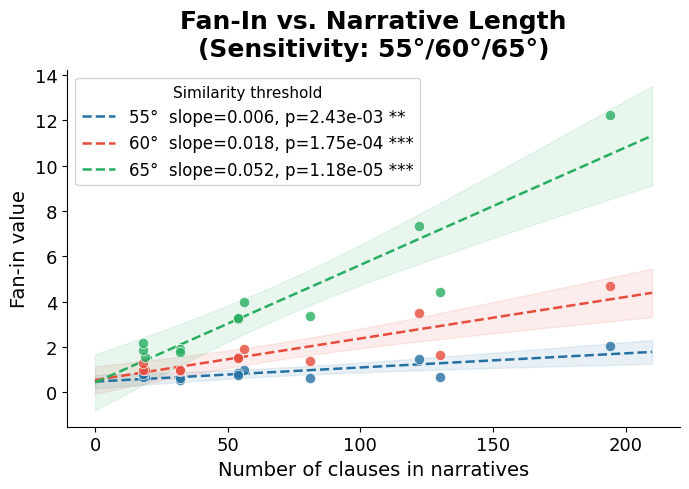


  Sensitivity — Fan-In regression
   Angle     slope      R²           p  sig
  --------------------------------------------------
     55°    0.0062   0.618  2.4257e-03  **
     60°    0.0183   0.770  1.7493e-04  ***
     65°    0.0519   0.865  1.1761e-05  ***


In [11]:
# ── overlaid plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for angle, col in zip(angles, colors):
    r   = sensitivity_results[angle]
    sig = ('***' if r['p'] < 0.001 else '**' if r['p'] < 0.01
           else '*' if r['p'] < 0.05 else 'ns')
    ax.scatter(clause_story, r['F_in_mean'], color=col, s=55,
               edgecolors='white', linewidths=0.6, zorder=3, alpha=0.8)
    ax.plot(r['x_reg'], r['pred']['mean'], '--', color=col, lw=1.8,
            label=f"{angle}°  slope={r['slope']:.3f}, p={r['p']:.2e} {sig}")
    ax.fill_between(r['x_reg'],
                    r['pred']['mean_ci_lower'], r['pred']['mean_ci_upper'],
                    color=col, alpha=0.10)

ax.set_title("Fan-In vs. Narrative Length\n(Sensitivity: 55°/60°/65°)",
             fontsize=18, fontweight='bold', pad=10)
ax.set_xlabel("Number of clauses in narratives", fontsize=14)
ax.set_ylabel("Fan-in value",                    fontsize=14)
ax.tick_params(labelsize=13)
ax.legend(fontsize=12, title="Similarity threshold", title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fanin_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  Sensitivity — Fan-In regression")
print(f"{'='*55}")
print(f"  {'Angle':>6}  {'slope':>8}  {'R²':>6}  {'p':>10}  sig")
print(f"  {'-'*50}")
for angle in angles:
    r   = sensitivity_results[angle]
    sig = ('***' if r['p'] < 0.001 else '**' if r['p'] < 0.01
           else '*' if r['p'] < 0.05 else 'ns')
    print(f"  {angle:>5}°  {r['slope']:>8.4f}  {r['r_sq']:>6.3f}  {r['p']:>10.4e}  {sig}")
print(f"{'='*55}")